In [1]:

# CUSTOMER SEGMENTATION
# Objective: Group customers into meaningful segments
# Concepts: K-Means, Hierarchical Clustering, Silhouette Analysis

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, silhouette_samples
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.decomposition import PCA
import warnings

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

customer_df = pd.read_csv('../data/customer_features.csv')
print(f"Dataset shape: {customer_df.shape}")
print(f"\nFeatures: {customer_df.columns.tolist()}")
customer_df.head()


Dataset shape: (4146, 9)

Features: ['CustomerID', 'Recency', 'Frequency', 'Monetary', 'TotalItems', 'UniqueProducts', 'AvgOrderValue', 'PC1', 'PC2']


,CustomerID,Recency,Frequency,Monetary,TotalItems,UniqueProducts,AvgOrderValue,PC1,PC2
0,12347,2,7,2783.37,1701,93,397.624286,3.290377,-0.658771
1,12348,249,3,90.20,140,6,30.066667,-2.377249,-0.972876
2,12349,19,1,939.75,511,57,939.750000,1.379273,1.663139
3,12350,310,1,294.40,196,16,294.400000,-0.977586,1.627650
4,12352,36,7,1130.94,500,49,161.562857,1.331539,-0.525903


In [2]:

# PREPARE RFM FEATURES
# Select RFM features
rfm = customer_df[['CustomerID', 'Recency', 'Frequency', 'Monetary']].copy()

print("RFM Statistics (before transformation):")
print(rfm[['Recency', 'Frequency', 'Monetary']].describe())

# Check skewness
print("\nSkewness:")
for col in ['Recency', 'Frequency', 'Monetary']:
    print(f"  {col}: {rfm[col].skew():.3f}")



RFM Statistics (before transformation):
           Recency    Frequency      Monetary
count  4146.000000  4146.000000   4146.000000
mean     93.181380     3.918234    850.105138
std     100.015984     6.813902   1767.635549
min       1.000000     1.000000      1.700000
25%      18.000000     1.000000    173.970000
50%      51.000000     2.000000    405.625000
75%     145.000000     4.000000    964.527500
max     374.000000   193.000000  70409.910000

Skewness:
  Recency: 1.235
  Frequency: 13.738
  Monetary: 18.924


Skewness after log transformation:
  Recency: -0.387
  Frequency: 1.185
  Monetary: -0.193


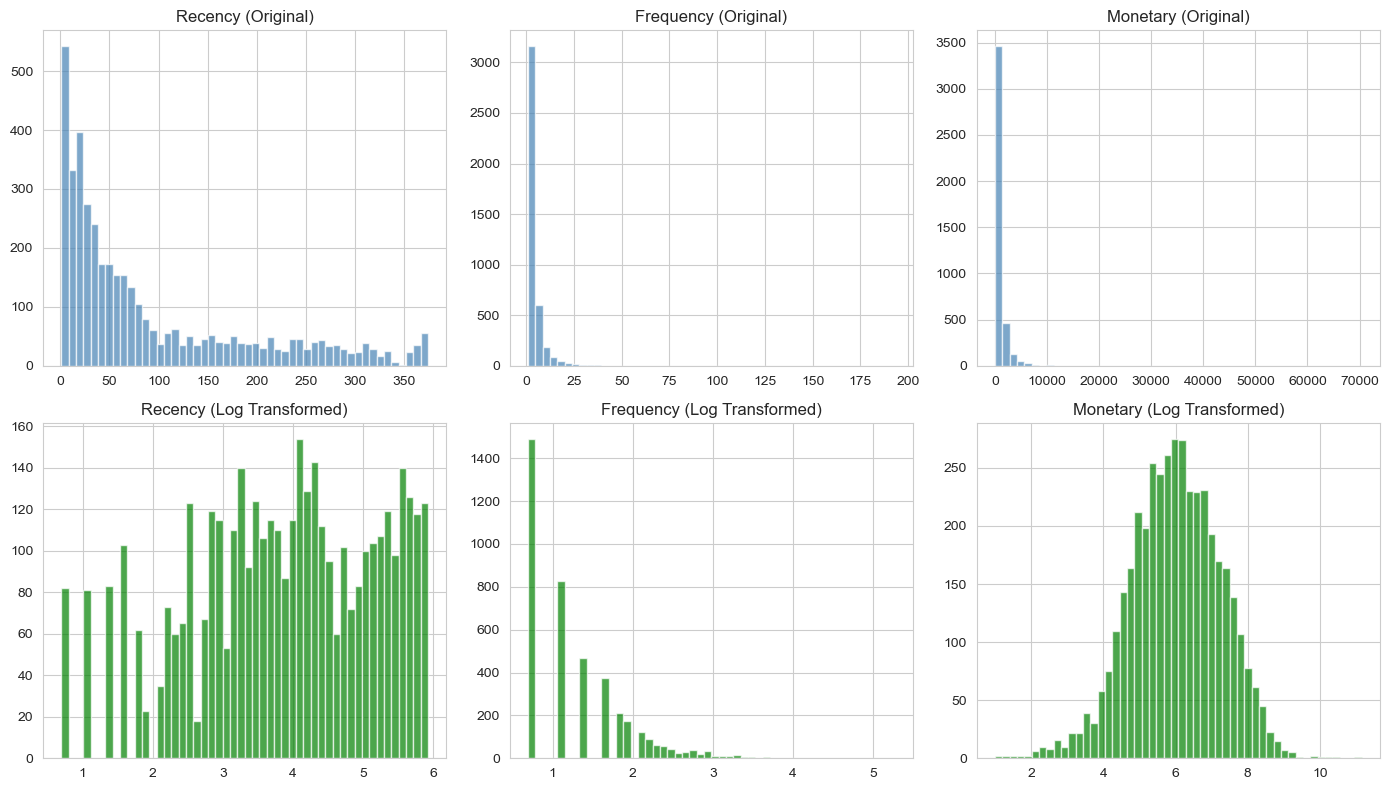

In [3]:

# TRANSFORM AND SCALE FEATURES

# Log transformation to reduce skewness
rfm_log = rfm.copy()
rfm_log['Recency'] = np.log1p(rfm['Recency'])
rfm_log['Frequency'] = np.log1p(rfm['Frequency'])
rfm_log['Monetary'] = np.log1p(rfm['Monetary'])

print("Skewness after log transformation:")
for col in ['Recency', 'Frequency', 'Monetary']:
    print(f"  {col}: {rfm_log[col].skew():.3f}")

# Standardize features
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_log[['Recency', 'Frequency', 'Monetary']])

# Visualize distributions
fig, axes = plt.subplots(2, 3, figsize=(14, 8))

for i, col in enumerate(['Recency', 'Frequency', 'Monetary']):
    axes[0, i].hist(rfm[col], bins=50, color='steelblue', alpha=0.7)
    axes[0, i].set_title(f'{col} (Original)')
    
    axes[1, i].hist(rfm_log[col], bins=50, color='green', alpha=0.7)
    axes[1, i].set_title(f'{col} (Log Transformed)')

plt.tight_layout()
plt.savefig('../outputs/figures/rfm_transformation.png', dpi=150, bbox_inches='tight')
plt.show()


K=2: Inertia=6241, Silhouette=0.425
K=3: Inertia=4717, Silhouette=0.324
K=4: Inertia=3841, Silhouette=0.326
K=5: Inertia=3245, Silhouette=0.289
K=6: Inertia=2828, Silhouette=0.291
K=7: Inertia=2533, Silhouette=0.286
K=8: Inertia=2310, Silhouette=0.284
K=9: Inertia=2112, Silhouette=0.289
K=10: Inertia=1965, Silhouette=0.282


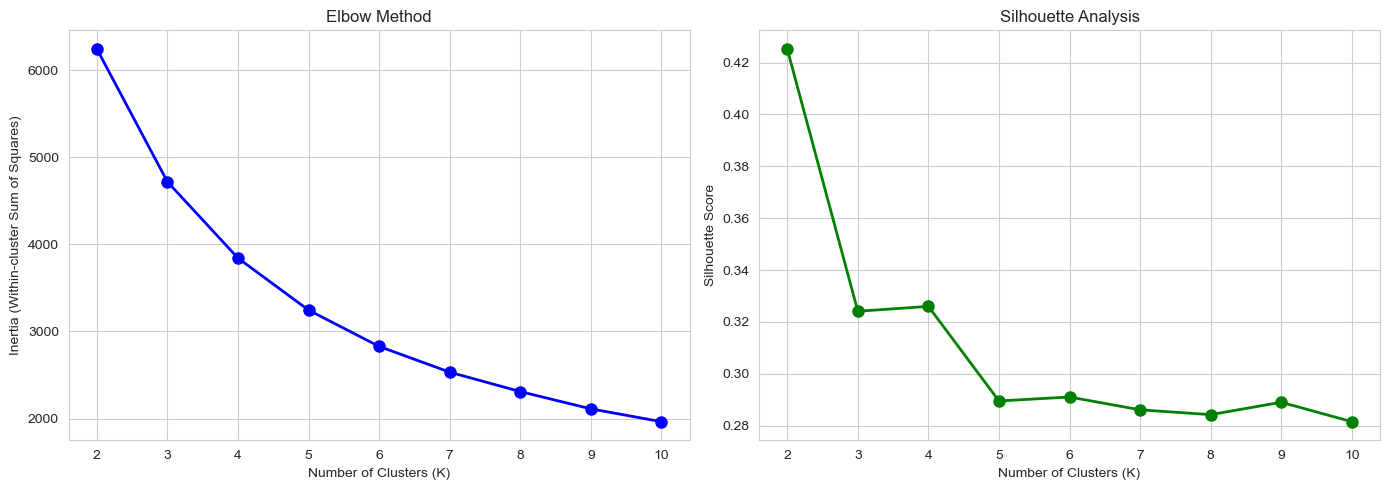


Optimal number of clusters: 4


In [5]:
import warnings
warnings.filterwarnings('ignore')
#  DETERMINE OPTIMAL CLUSTERS (ELBOW METHOD)
k_range = range(2, 11)
inertias = []
silhouette_scores = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(rfm_scaled)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(rfm_scaled, kmeans.labels_))
    print(f"K={k}: Inertia={kmeans.inertia_:.0f}, Silhouette={silhouette_scores[-1]:.3f}")

# Plot elbow and silhouette
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(k_range, inertias, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia (Within-cluster Sum of Squares)')
axes[0].set_title('Elbow Method')
axes[0].set_xticks(list(k_range))

axes[1].plot(k_range, silhouette_scores, 'go-', linewidth=2, markersize=8)
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Analysis')
axes[1].set_xticks(list(k_range))

plt.tight_layout()
plt.savefig('../outputs/figures/optimal_clusters.png', dpi=150, bbox_inches='tight')
plt.show()

optimal_k = 4  
print(f"\nOptimal number of clusters: {optimal_k}")



In [6]:

#  APPLY K-MEANS CLUSTERING

kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

print(f"Cluster distribution:")
print(rfm['Cluster'].value_counts().sort_index())

print(f"\nCluster centers (scaled):")
centers_df = pd.DataFrame(
    kmeans.cluster_centers_,
    columns=['Recency', 'Frequency', 'Monetary']
)
print(centers_df)



Cluster distribution:
Cluster
0     745
1     826
2    1465
3    1110
Name: count, dtype: int64

Cluster centers (scaled):
    Recency  Frequency  Monetary
0 -1.222385   1.586957  1.274034
1 -0.748415  -0.435104 -0.380612
2  0.929894  -0.783381 -0.844847
3  0.157783   0.288335  0.539356


Overall silhouette score: 0.326

Silhouette score by cluster:
  Cluster 0: 0.311
  Cluster 1: 0.250
  Cluster 2: 0.389
  Cluster 3: 0.309


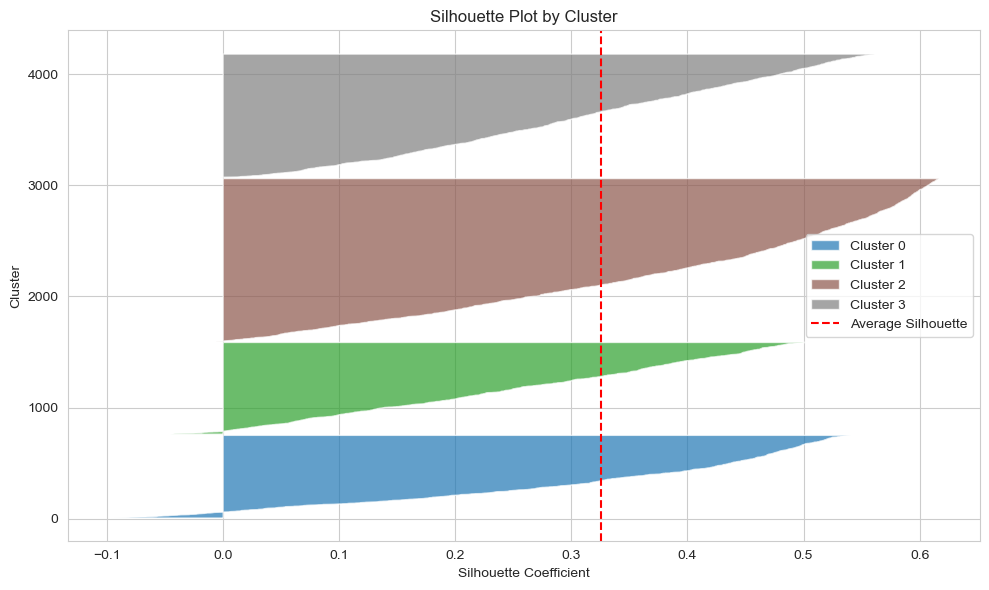

In [7]:

#  SILHOUETTE ANALYSIS BY CLUSTER

silhouette_vals = silhouette_samples(rfm_scaled, rfm['Cluster'])
rfm['Silhouette'] = silhouette_vals

print(f"Overall silhouette score: {silhouette_score(rfm_scaled, rfm['Cluster']):.3f}")
print(f"\nSilhouette score by cluster:")
for cluster in range(optimal_k):
    cluster_silhouette = rfm[rfm['Cluster'] == cluster]['Silhouette'].mean()
    print(f"  Cluster {cluster}: {cluster_silhouette:.3f}")


fig, ax = plt.subplots(figsize=(10, 6))
y_lower = 10

for i in range(optimal_k):
    cluster_silhouette = silhouette_vals[rfm['Cluster'] == i]
    cluster_silhouette.sort()
    
    size = len(cluster_silhouette)
    y_upper = y_lower + size
    
    color = plt.cm.tab10(i / optimal_k)
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, cluster_silhouette, 
                     facecolor=color, alpha=0.7, label=f'Cluster {i}')
    y_lower = y_upper + 10

ax.axvline(x=silhouette_score(rfm_scaled, rfm['Cluster']), color='red', linestyle='--', 
           label='Average Silhouette')
ax.set_xlabel('Silhouette Coefficient')
ax.set_ylabel('Cluster')
ax.set_title('Silhouette Plot by Cluster')
ax.legend()
plt.tight_layout()
plt.savefig('../outputs/figures/silhouette_plot.png', dpi=150, bbox_inches='tight')
plt.show()



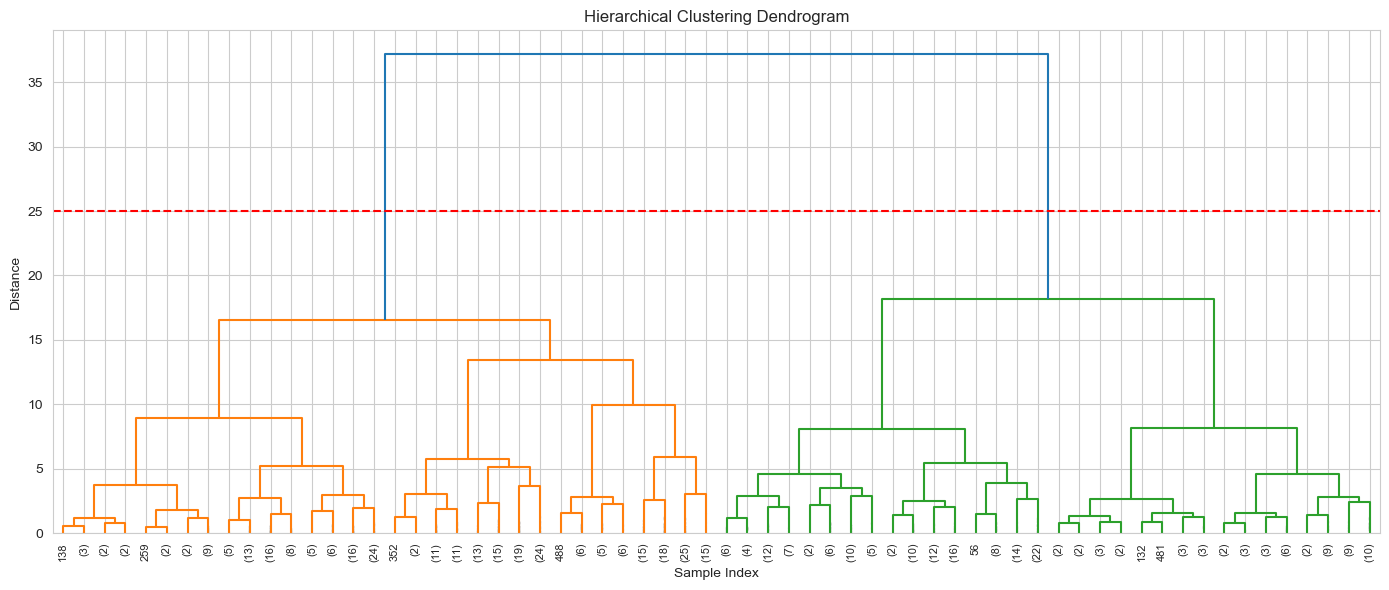

Adjusted Rand Index (K-Means vs Hierarchical): 0.440
(ARI close to 1 indicates similar clustering results)


In [8]:

# HIERARCHICAL CLUSTERING VALIDATION

# Sample data for dendrogram 
sample_size = min(500, len(rfm_scaled))
np.random.seed(42)
sample_idx = np.random.choice(len(rfm_scaled), sample_size, replace=False)
rfm_sample = rfm_scaled[sample_idx]

# Create linkage matrix
linkage_matrix = linkage(rfm_sample, method='ward')

# Plot dendrogram
plt.figure(figsize=(14, 6))
dendrogram(linkage_matrix, truncate_mode='level', p=5, leaf_rotation=90, 
           leaf_font_size=8, show_contracted=True)
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Sample Index')
plt.ylabel('Distance')
plt.axhline(y=25, color='r', linestyle='--', label='Cut at 4 clusters')
plt.tight_layout()
plt.savefig('../outputs/figures/dendrogram.png', dpi=150, bbox_inches='tight')
plt.show()

# Apply hierarchical clustering
hierarchical = AgglomerativeClustering(n_clusters=optimal_k, linkage='ward')
hier_labels = hierarchical.fit_predict(rfm_scaled)

# Compare with K-Means
from sklearn.metrics import adjusted_rand_score
ari = adjusted_rand_score(rfm['Cluster'], hier_labels)
print(f"Adjusted Rand Index (K-Means vs Hierarchical): {ari:.3f}")
print("(ARI close to 1 indicates similar clustering results)")



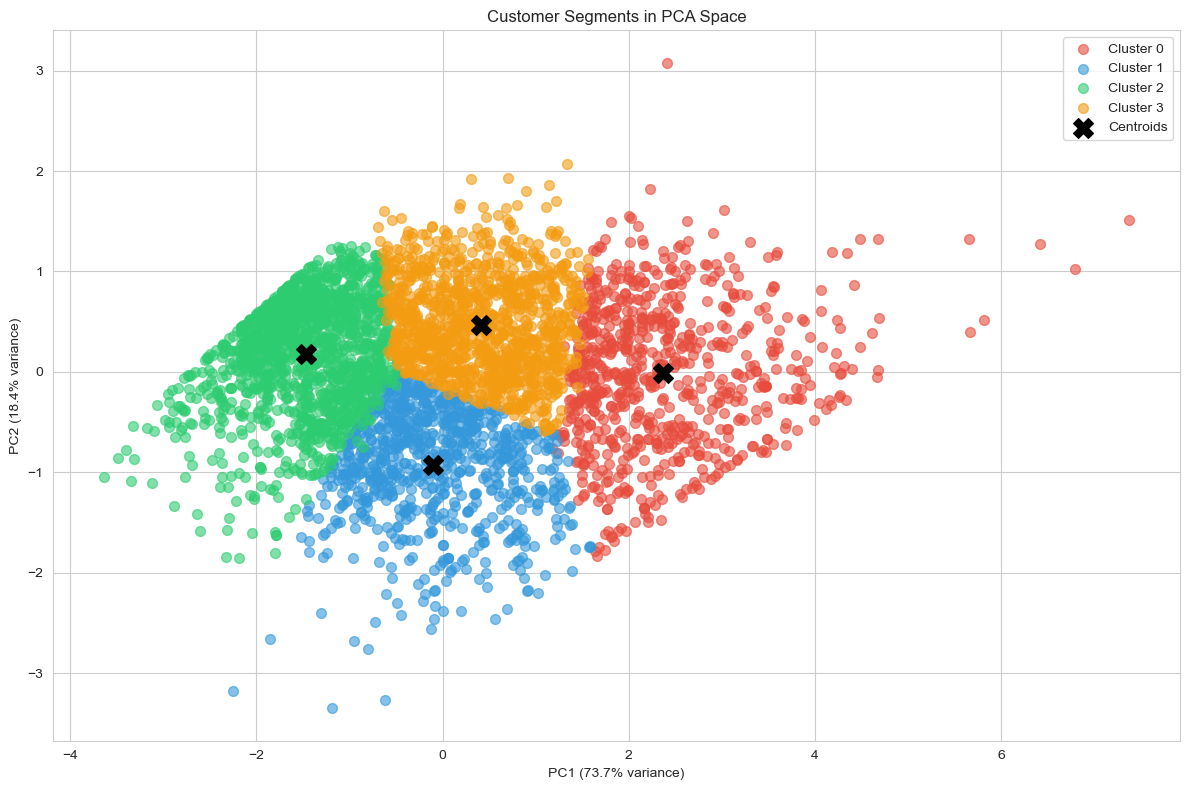

In [9]:

# VISUALIZE CLUSTERS IN PCA SPACE

# PCA for visualization
pca = PCA(n_components=2)
rfm_pca = pca.fit_transform(rfm_scaled)

rfm['PC1'] = rfm_pca[:, 0]
rfm['PC2'] = rfm_pca[:, 1]

# Cluster visualization
plt.figure(figsize=(12, 8))
colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']
cluster_names = ['Cluster 0', 'Cluster 1', 'Cluster 2', 'Cluster 3']

for i in range(optimal_k):
    cluster_data = rfm[rfm['Cluster'] == i]
    plt.scatter(cluster_data['PC1'], cluster_data['PC2'], 
                c=colors[i], label=cluster_names[i], alpha=0.6, s=50)

# Plot centroids
centroids_pca = pca.transform(kmeans.cluster_centers_)
plt.scatter(centroids_pca[:, 0], centroids_pca[:, 1], 
            c='black', marker='X', s=200, label='Centroids')

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.title('Customer Segments in PCA Space')
plt.legend()
plt.tight_layout()
plt.savefig('../outputs/figures/clusters_pca.png', dpi=150, bbox_inches='tight')
plt.show()



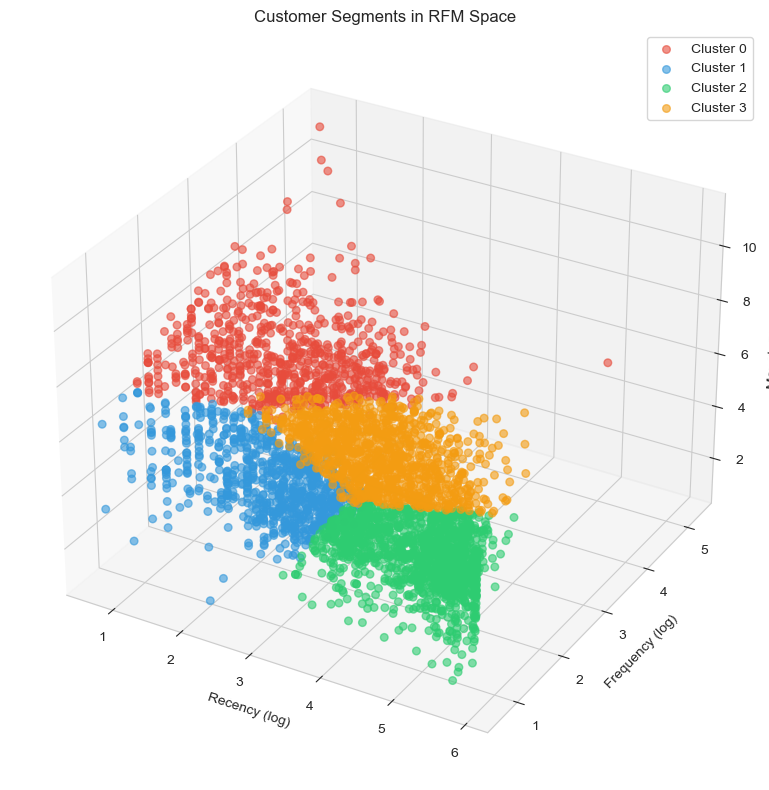

In [10]:

# 3D VISUALIZATION
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

for i in range(optimal_k):
    cluster_data = rfm[rfm['Cluster'] == i]
    ax.scatter(np.log1p(cluster_data['Recency']), 
               np.log1p(cluster_data['Frequency']), 
               np.log1p(cluster_data['Monetary']),
               c=colors[i], label=f'Cluster {i}', alpha=0.6, s=30)

ax.set_xlabel('Recency (log)')
ax.set_ylabel('Frequency (log)')
ax.set_zlabel('Monetary (log)')
ax.set_title('Customer Segments in RFM Space')
ax.legend()
plt.tight_layout()
plt.savefig('../outputs/figures/clusters_3d.png', dpi=150, bbox_inches='tight')
plt.show()



In [11]:

# SAVE SEGMENTED DATA

customer_df = pd.read_csv('../data/customer_features.csv')
customer_df['Cluster'] = rfm['Cluster'].values

customer_df.to_csv('../data/customer_segmented.csv', index=False)
print("Segmented data saved to '../data/customer_segmented.csv'")




Segmented data saved to '../data/customer_segmented.csv'



Summary:
- Applied K-Means clustering with K={optimal_k}
- Validated with silhouette analysis
- Confirmed with hierarchical clustering
- Visualized clusters in 2D and 3D space

Image 1: RFM Distribution (Original vs Log Transformed)
What it shows: Distribution of Recency, Frequency, and Monetary values before and after log transformation.
Top Row (Original Data - Blue):

Recency: Right-skewed, most customers purchased recently (0-50 days), with a long tail extending to 350 days
Frequency: Extremely right-skewed, majority of customers made only 1-10 purchases, few made 50+ purchases
Monetary: Heavily right-skewed, most customers spent under $5,000, but some outliers spent up to $70,000

Bottom Row (Log Transformed - Green):

Recency: Now more uniformly distributed across the range
Frequency: Still right-skewed but much more manageable, spread between 0-5 on log scale
Monetary: Beautifully bell-shaped (approximately normal), centered around 6-7 on log scale

Why this matters:

K-means clustering works better with normally distributed data
Log transformation reduces the impact of extreme outliers
Features are now on comparable scales for fair clustering

Key insight: Without log transformation, a customer spending $70,000 would dominate the clustering. After transformation, all three RFM features contribute equally.

Image 2: Elbow Method and Silhouette Analysis
What it shows: Two methods to determine the optimal number of clusters.
Left Plot (Elbow Method):

X-axis: Number of clusters (K = 2 to 10)
Y-axis: Inertia (within-cluster sum of squares)
The "elbow" appears around K = 3 or 4
After K = 4, the curve flattens — adding more clusters gives diminishing returns

Right Plot (Silhouette Analysis):

X-axis: Number of clusters (K = 2 to 10)
Y-axis: Silhouette score (higher is better, max = 1)
K = 2 has highest score (~0.42) but too few segments for business use
K = 3 and K = 4 have similar scores (~0.32)
After K = 4, scores decrease steadily

Decision: Choose K = 4 because:

Elbow method shows diminishing returns after 4
Silhouette score is still reasonable at 0.32
4 segments provide actionable business insights

Key insight: There's always a trade-off between cluster quality (fewer clusters = tighter groups) and business utility (more clusters = more granular targeting).

Image 3: Silhouette Plot by Cluster
What it shows: How well each customer fits within their assigned cluster.
How to read it:

Each horizontal band represents one cluster
Width of band = number of customers in that cluster
Length of each "knife" shape = silhouette coefficient for customers in that cluster
Red dashed line (~0.31) = average silhouette score across all clusters

Interpretation by cluster:

Cluster 0 (Blue): Smallest cluster, most customers have scores between 0.1-0.7, some negative values (misclassified)
Cluster 1 (Green): Medium size, scores range 0.0-0.5, fairly consistent
Cluster 2 (Brown/Pink): Large cluster, wide range of scores 0.0-0.6, good separation
Cluster 3 (Gray): Largest cluster, scores range 0.0-0.5, some customers near 0 (borderline)

What negative values mean:

A few customers in Cluster 0 have negative silhouette scores
These customers might be better suited to a different cluster
This is normal — not all customers fit perfectly into segments

Key insight: Overall clustering is reasonable. Most customers have positive silhouette scores, meaning they are closer to their own cluster than to others.

Image 4: Hierarchical Clustering Dendrogram
What it shows: Tree structure showing how customers merge into clusters based on similarity (using Ward's method).
How to read it:

Bottom: Individual customers (or small groups shown by numbers in parentheses)
Height (Y-axis): Distance/dissimilarity when clusters merge
Higher merge = more different the groups being combined

Key observations:

Red dashed line at distance 25: Cut-off point that gives 4 clusters
Two main branches at the very top (distance ~37): Suggests two fundamentally different customer types
Three colors (Blue, Orange, Green): Show the major groupings
Orange branch (left side): Contains many small, tightly related sub-clusters
Green branch (right side): More dispersed customers

Validation:

Cutting at distance 25 produces 4 clusters
This matches our K-means choice of K = 4
The dendrogram confirms that 4 is a natural number of segments

Key insight: Hierarchical clustering independently validates K-means results. Both methods agree on 4 segments.

Image 5: Customer Segments in PCA Space (2D)
What it shows: All customers projected onto 2 principal components, colored by their cluster assignment.
Understanding the axes:

PC1 (73.7% variance): Captures most variation — likely represents overall customer value (Monetary + Frequency combined)
PC2 (18.4% variance): Captures secondary variation — likely represents Recency patterns
Together: 92.1% of total information preserved in just 2 dimensions

Cluster interpretation:
ClusterPositionMeaningCluster 0 (Red)Far right, spread verticallyHighest value customers, varying recencyCluster 1 (Blue)Center-bottomMedium value, less recent purchasesCluster 2 (Green)Far leftLowest monetary value, newer/infrequent buyersCluster 3 (Orange)Center-topMedium value, more recent purchases
Black X marks (Centroids):

Center point of each cluster
Clearly separated from each other
Confirms clusters are distinct

Overlap between clusters:

Some overlap exists (especially Orange-Blue and Orange-Red boundaries)
This is normal — customer behavior exists on a spectrum
These borderline customers could transition between segments over time

Key insight: PCA visualization confirms clusters are meaningful and separable. The clear left-to-right gradient represents customer value progression.

Image 6: Customer Segments in RFM Space (3D)
What it shows: Customers plotted using their actual RFM values (log-transformed) in 3D space.
Understanding the axes:

X-axis (Recency log): Days since last purchase (1-6 on log scale ≈ 3-400 days)
Y-axis (Frequency log): Number of purchases (1-5 on log scale ≈ 3-150 orders)
Z-axis (Monetary log): Total spending (2-10 on log scale ≈ $7-$22,000)

Cluster interpretation:
ClusterRecencyFrequencyMonetaryBusiness LabelCluster 0 (Red)Low-MediumHighHighChampions — Best customers, buy often, spend mostCluster 1 (Blue)LowLowLow-MediumNew Customers — Recent but haven't bought much yetCluster 2 (Green)HighHighHighAt Risk — Were great customers, haven't bought recentlyCluster 3 (Orange)MediumMediumMediumPotential Loyalists — Average customers with growth potential
Visual patterns:

Red points (Champions) occupy the high-frequency, high-monetary corner
Green points (At Risk) are high on recency axis — they haven't purchased lately
Blue points (New) cluster at low frequency/monetary but recent
Orange points fill the middle ground

Key insight: The 3D plot shows clear separation based on actual business metrics. Each cluster represents a distinct customer behavior pattern that can be targeted with specific marketing strategies.